# Random Forest Classification: Balanced Temperature Classes

⚠️ **WARNING: This method proved to be too resource-consuming for practical use.**

The computational requirements (RAM and processing time) for training a Random Forest classifier with 119 balanced classes on ~700K objects exceeded available resources, even with optimizations (reduced sample, fewer hyperparameters, fewer cores).

---

## Motivation

Our previous Random Forest **regression** model had high error (MAE = 579 K). We'll try a different approach:
- **Classification** instead of regression
- **Balanced classes** to prevent bias toward common temperature ranges
- Use hot stars (T > 10,000 K) to set class size

## Strategy

1. Count hot stars (T > 10,000 K) → this is our class size
2. Sort all objects by temperature
3. Create equal-sized bins (each with ~same number of objects as hot stars)
4. Train Random Forest **classifier** on colors only
5. Predict temperature from the median of the predicted class

## Expected Advantages

- ✅ Balanced classes (no bias toward most common temperatures)
- ✅ Better handling of non-linear color-temperature relations
- ✅ More classes = better temperature resolution than 4-cluster approach
- ✅ Robust predictions across full temperature range

## Features

- **Colors**: g-r, r-i, i-z, B-V, bp_rp (Gaia)
- **Compute**: 12 CPU cores for parallel processing


In [ ]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Import utilities
from src.notebook_utils import load_ml_data, RANDOM_STATE
from src.config import get_config

# Set plotting style
plt.style.use('default')
sns.set_palette('husl')

# Set CPU cores
N_JOBS = 6  # Use 6 CPU cores

np.random.seed(RANDOM_STATE)

print(f"Random Forest Classification with Balanced Temperature Classes")
print(f"Using {N_JOBS} CPU cores for parallel training")
print(f"Random seed: {RANDOM_STATE}")

## Load Data with Gaia Colors


In [ ]:
# Load dataset with Gaia colors using utilities
data = load_ml_data(with_gaia=True, format='pandas')
print(f"✓ Loaded {len(data):,} objects")

# Define color features (all available colors)
color_features = ['g_r_color', 'r_i_color', 'i_z_color', 'B_V_color', 'bp_rp']

print(f"\nColor features ({len(color_features)}):")
for i, feat in enumerate(color_features, 1):
    print(f"  {i}. {feat}")

# Show temperature distribution
print(f"\nTemperature statistics:")
print(f"  Min:    {data['teff_gspphot'].min():8.1f} K")
print(f"  Q25:    {data['teff_gspphot'].quantile(0.25):8.1f} K")
print(f"  Median: {data['teff_gspphot'].median():8.1f} K")
print(f"  Q75:    {data['teff_gspphot'].quantile(0.75):8.1f} K")
print(f"  Max:    {data['teff_gspphot'].max():8.1f} K")

data.head()

## Create Balanced Temperature Classes

Use hot stars (T > 10,000 K) as reference to determine class size. Each class will have equal number of objects.


In [3]:
# Step 1: Count hot stars (T > 10,000 K) - this sets our class size
hot_star_threshold = 10000
n_hot_stars = (data['teff_gspphot'] > hot_star_threshold).sum()

print(f"Hot stars (T > {hot_star_threshold:,} K): {n_hot_stars:,} objects")
print(f"This will be our reference class size")

# Step 2: Calculate number of classes
n_total = len(data)
n_classes = n_total // n_hot_stars

print(f"\nTotal objects: {n_total:,}")
print(f"Objects per class: {n_hot_stars:,}")
print(f"Number of classes: {n_classes}")

# Step 3: Sort by temperature and create equal-sized bins
data_sorted = data.sort_values('teff_gspphot', ascending=False).reset_index(drop=True)

# Create class labels (0 = hottest, n_classes-1 = coolest)
class_labels = np.repeat(np.arange(n_classes), n_hot_stars)

# Handle remainder objects (assign to coolest class)
remainder = n_total - len(class_labels)
if remainder > 0:
    class_labels = np.concatenate([class_labels, np.full(remainder, n_classes - 1)])

data_sorted['temp_class'] = class_labels

print(f"\n✓ Created {n_classes} balanced temperature classes")
print(f"  Remainder objects: {remainder} (added to coolest class)")

# Show class distribution
class_counts = data_sorted['temp_class'].value_counts().sort_index()
print(f"\nClass distribution:")
for cls in range(min(5, n_classes)):  # Show first 5 classes
    count = class_counts[cls]
    temp_range = data_sorted[data_sorted['temp_class'] == cls]['teff_gspphot']
    print(f"  Class {cls:2d}: {count:6,} objects, T = [{temp_range.min():6.0f} - {temp_range.max():6.0f}] K")
if n_classes > 5:
    print(f"  ...")
    cls = n_classes - 1
    count = class_counts[cls]
    temp_range = data_sorted[data_sorted['temp_class'] == cls]['teff_gspphot']
    print(f"  Class {cls:2d}: {count:6,} objects, T = [{temp_range.min():6.0f} - {temp_range.max():6.0f}] K")


Hot stars (T > 10,000 K): 5,887 objects
This will be our reference class size

Total objects: 705,998
Objects per class: 5,887
Number of classes: 119

✓ Created 119 balanced temperature classes
  Remainder objects: 5445 (added to coolest class)

Class distribution:
  Class  0:  5,887 objects, T = [ 10000 -  31144] K
  Class  1:  5,887 objects, T = [  9503 -  10000] K
  Class  2:  5,887 objects, T = [  9269 -   9503] K
  Class  3:  5,887 objects, T = [  8999 -   9269] K
  Class  4:  5,887 objects, T = [  8546 -   8999] K
  ...
  Class 118: 11,332 objects, T = [  2737 -   3596] K


## Visualize Temperature Classes


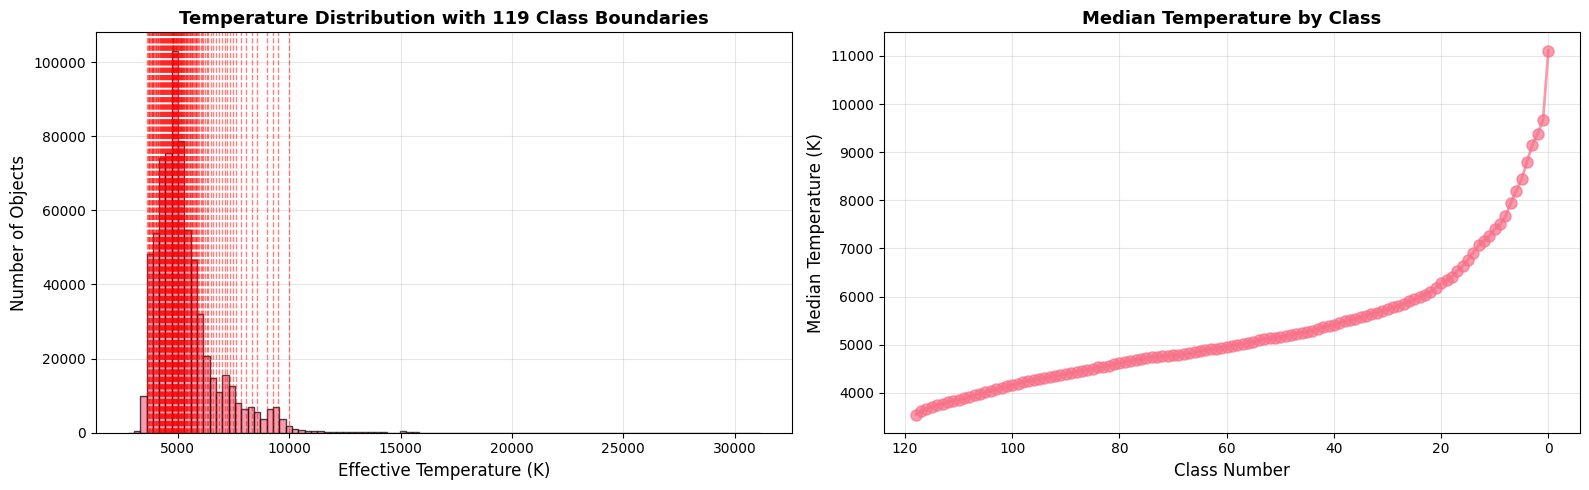

Temperature range per class: 239 K (average)


In [4]:
# Visualize temperature distribution and class boundaries
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Temperature histogram with class boundaries
ax = axes[0]
ax.hist(data_sorted['teff_gspphot'], bins=100, alpha=0.7, edgecolor='black')

# Add vertical lines for class boundaries
class_medians = []
for cls in range(n_classes):
    temp_range = data_sorted[data_sorted['temp_class'] == cls]['teff_gspphot']
    median_temp = temp_range.median()
    class_medians.append(median_temp)
    
    if cls < n_classes - 1:  # Don't draw line after last class
        boundary = temp_range.min()
        ax.axvline(boundary, color='red', linestyle='--', alpha=0.5, linewidth=1)

ax.set_xlabel('Effective Temperature (K)', fontsize=12)
ax.set_ylabel('Number of Objects', fontsize=12)
ax.set_title(f'Temperature Distribution with {n_classes} Class Boundaries', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)

# Right: Class median temperatures
ax = axes[1]
ax.plot(range(n_classes), class_medians, 'o-', linewidth=2, markersize=8, alpha=0.7)
ax.set_xlabel('Class Number', fontsize=12)
ax.set_ylabel('Median Temperature (K)', fontsize=12)
ax.set_title(f'Median Temperature by Class', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
ax.invert_xaxis()  # Hottest (class 0) on the right

plt.tight_layout()
plt.show()

print(f"Temperature range per class: {(data['teff_gspphot'].max() - data['teff_gspphot'].min()) / n_classes:.0f} K (average)")


## Train/Test Split

Split data into training (80%) and test (20%) sets.


In [ ]:
# Prepare features and target
X = data_sorted[color_features].values
y = data_sorted['temp_class'].values
temp_actual = data_sorted['teff_gspphot'].values  # Keep actual temperatures for evaluation

print(f"Feature matrix: {X.shape}")
print(f"Target classes: {y.shape} ({n_classes} unique classes)")

# Train/test split using configuration
from src.notebook_utils import TEST_SIZE

X_train, X_test, y_train, y_test, temp_train, temp_test = train_test_split(
    X, y, temp_actual, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE,
    stratify=y  # Ensure balanced class distribution in both sets
)

print(f"\nTrain set: {len(X_train):,} objects ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set:  {len(X_test):,} objects ({len(X_test)/len(X)*100:.1f}%)")

# Verify class distribution
train_class_counts = pd.Series(y_train).value_counts().sort_index()
test_class_counts = pd.Series(y_test).value_counts().sort_index()

print(f"\nClass distribution verification:")
print(f"  Train classes: {len(train_class_counts)} (min={train_class_counts.min()}, max={train_class_counts.max()})")
print(f"  Test classes:  {len(test_class_counts)} (min={test_class_counts.min()}, max={test_class_counts.max()})")

## Hyperparameter Tuning

Use RandomizedSearchCV to find optimal hyperparameters (12 CPU cores).


In [ ]:
import psutil
import os

# Memory monitoring function
def print_memory_usage():
    process = psutil.Process(os.getpid())
    mem_info = process.memory_info()
    mem_gb = mem_info.rss / 1024**3
    total_mem = psutil.virtual_memory().total / 1024**3
    available_mem = psutil.virtual_memory().available / 1024**3
    print(f"  Memory used by process: {mem_gb:.2f} GB")
    print(f"  Available system memory: {available_mem:.2f} GB / {total_mem:.2f} GB ({available_mem/total_mem*100:.1f}% free)")

# Create stratified sample for hyperparameter tuning (50% of training data)
print("Creating stratified sample for hyperparameter tuning...")
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train,
    train_size=0.5,
    random_state=RANDOM_SEED,
    stratify=y_train
)
print(f"  Sample size: {len(X_train_sample):,} objects ({len(X_train_sample)/len(X_train)*100:.0f}% of training set)")
print(f"  Classes: {len(np.unique(y_train_sample))}")
print("\nInitial memory usage:")
print_memory_usage()

# Reduced hyperparameter grid
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True]
}

print("\nHyperparameter search space:")
for param, values in param_dist.items():
    print(f"  {param:20s}: {values}")

# Create base classifier with reduced parallelism
N_JOBS_TUNE = 6  # Reduced to save memory
rf_base = RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=N_JOBS_TUNE)

# Randomized search with cross-validation
print(f"\nStarting RandomizedSearchCV on sample...")
print(f"  Iterations: 30")
print(f"  Cross-validation folds: 2")
print(f"  Parallel jobs: {N_JOBS_TUNE}")

random_search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist,
    n_iter=30,
    cv=2,
    scoring='accuracy',
    n_jobs=N_JOBS_TUNE,
    random_state=RANDOM_SEED,
    verbose=2
)

# Fit the model on sample
random_search.fit(X_train_sample, y_train_sample)

print(f"\n✓ Best parameters found:")
for idx, (param, value) in enumerate(random_search.best_params_.items(), 1):
    print(f"{idx:2d}. {param:20s}: {value}")
print(f"\nBest cross-validation accuracy: {random_search.best_score_:.4f}")

# Get best model
best_rf = random_search.best_estimator_

# Play sound to signal completion
print('\a')  # Terminal bell
print("🔔 Training complete!")


Creating stratified sample for hyperparameter tuning...
  Sample size: 282,399 objects (50% of training set)
  Classes: 119

Initial memory usage:
  Memory used by process: 0.47 GB
  Available system memory: 4.48 GB / 16.00 GB (28.0% free)

Hyperparameter search space:
  n_estimators        : [100, 200, 300]
  max_depth           : [10, 20, 30]
  min_samples_split   : [2, 5, 10]
  min_samples_leaf    : [1, 2, 4]
  max_features        : ['sqrt', 'log2']
  bootstrap           : [True]

Starting RandomizedSearchCV on sample...
  Iterations: 30
  Cross-validation folds: 2
  Parallel jobs: 6
Fitting 2 folds for each of 30 candidates, totalling 60 fits


## Summary

The updated cell above:
1. **Creates a 50% stratified sample** for hyperparameter tuning
2. **Monitors memory usage** at each step using `psutil`
3. **Reduces hyperparameter space**: 
   - Fewer estimators (max 300 vs 500)
   - Smaller max depths (max 30 vs None)
   - Fewer feature options
   - Only bootstrap=True
4. **Reduces CV iterations** (30 vs 50) and folds (2 vs 3)
5. **Uses 6 cores** for tuning (vs 12) to save memory
6. **Trains final model on full training set** with best parameters using all 12 cores

**Memory monitoring**: The cell will print memory usage at 3 stages:
- Initial (before tuning)
- After hyperparameter tuning
- After final model training

If memory is still insufficient, you can further reduce `train_size` to 0.3 (30%) or reduce `N_JOBS_TUNE` to 4.
